# Exp 12B — Deterministic-first residual resolver (architecture probe, development only)
**Question:** Exp 12 showed pure rules (48/70) beat the best hybrid (33/70), with the hybrid's gain coming almost entirely from resolved evidence facts. Can we preserve deterministic reliability and use the LLM only where the deterministic layer genuinely cannot resolve the case?

**Not the final router (that is Exp 30).** This is a small probe of the resolver shape:
```text
Claim -> deterministic evaluation -> conclusive? -> YES: use the deterministic decision (authoritative, no LLM vote)
                                                  -> NO: unresolved semantic issue -> LLM (R2) or always ESCALATE (R1)
```
**Conclusiveness is defined from runtime-visible state only** (never case_family, expected outcome, or any evaluator field): a case is **conclusive** if the deterministic rule engine (`src/rules_text.py` + `src/rules_v2.py`, unchanged since Exp 2c) reached a decision other than its generic "no rule triggered" fallback, **and** every note-parsed field that expense type's logic needs was actually extracted (not `None`). Both conditions are visible from the parser's own output and the rule engine's own reason string — no label is read.

**Variants, development only:**
| Variant | Architecture |
|---|---|
| R0 | Deterministic rules only (Exp 2c, reused, $0) |
| R1 | Deterministic where conclusive; unresolved cases always ESCALATE |
| R2 | Deterministic where conclusive; unresolved cases sent to the LLM (RAG + Exp 12's H4 facts) |

The key comparison is **R1 vs R2**: does LLM adjudication of genuine ambiguity beat simply escalating it?

In [1]:
import json, os, sys
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd().parents[1]; sys.path.insert(0, str(ROOT))
from src import config as C, llm, llm_exp, retrieval, retrievers, embed, evaluate, metrics_ext, rules_text as RT, rules_v2 as RV, hybrid_facts as HF
C.load_env()
pd.set_option('display.width', 260, 'display.max_columns', 40, 'display.max_colwidth', 100, 'display.max_rows', 200)
EXP = 'EXP12B_RESOLVER'; EMB = 'voyageai/voyage-4-lite'; CFG = 'fixed600_100'; K = 8
gt = evaluate.load_gt(); cases = llm_exp.cases_for('DEVELOPMENT')
NEEDED = {'MEAL_CLIENT': ['attendees_total','external_names'], 'MEAL_EMPLOYEE': ['attendees_total'], 'HOTEL': ['nights'], 'AIRFARE': ['cabin','flight_hours'], 'MILEAGE': ['distance_km'],
          'GIFT': ['recipient_name','recipient_org'], 'SOFTWARE': ['business_owner'], 'TRAINING': ['learning_plan_id'], 'GROUND_TRANSPORT': ['origin','destination'],
          'TELECOM': [], 'EQUIPMENT': [], 'CONFERENCE_FEE': [], 'CAR_RENTAL': [], 'OTHER': []}
def deterministic(c):
    f = RT.parse(c); cc = dict(c, form=f); d = RV.decide(cc)
    unresolved_field = any(f.get(k) is None for k in NEEDED.get(f.get('expense_type'), []))
    fallback = d['reason'] == 'No rule triggered.'
    return d, (not fallback and not unresolved_field), f
DET = {c['case_id']: deterministic(c) for c in cases}
n_conclusive = sum(v[1] for v in DET.values())
print(f'{n_conclusive} of {len(cases)} dev claims resolved conclusively by the deterministic layer (visible-only signal, no labels read)')
print('spent so far $%.4f of $%s' % (llm.spent(), os.environ['MAX_BUDGET_USD']))

34 of 70 dev claims resolved conclusively by the deterministic layer (visible-only signal, no labels read)
spent so far $1.9735 of $3.50


## R0: deterministic rules only (reused from Exp 2c)

In [2]:
s2c = json.loads((C.RESULTS/'development'/'exp02_rules'/'summary_2c_regex_development.json').read_text())
r2c = [json.loads(l) for l in (C.RESULTS/'development'/'exp02_rules'/'predictions_2c_regex_development.jsonl').read_text().splitlines()]
print('R0 (rules only):', s2c['correct'], '/', s2c['n'])

R0 (rules only): 48 / 70


## R1: deterministic where conclusive, ESCALATE otherwise (no LLM)

In [3]:
r1_recs = []
for c in cases:
    d, conc, f = DET[c['case_id']]
    dec = d if conc else {'decision':'ESCALATE','policy_evidence':[],'missing_fields':[],'reason':'unresolved: deterministic layer not conclusive','manual_review_required':True}
    r1_recs.append({'case_id': c['case_id'], 'predicted_decision': dec['decision'], 'policy_evidence': dec.get('policy_evidence',[]), 'missing_fields': dec.get('missing_fields',[]),
                     'manual_review_required': dec['decision']=='ESCALATE', 'latency_ms': 0, 'input_tokens': 0, 'output_tokens': 0, 'model_cost_usd': 0.0, 'error': None})
s1, rows1 = evaluate.evaluate(r1_recs, gt); ext1 = metrics_ext.extended(r1_recs)
print('R1 (escalate unresolved):', s1['correct'], '/', s1['n'], '| escalation rate', round(sum(r['manual_review_required'] for r in r1_recs)/70,3))

R1 (escalate unresolved): 36 / 70 | escalation rate 0.657


## R2: deterministic where conclusive, LLM for the unresolved residual only

In [4]:
R = retrievers.Retriever(EMB, CFG)
CATMAP = {'TRAVEL': {'travel','transport','training'}, 'FOOD_AND_DRINK': {'meals'}, 'TECH_AND_SUPPLIES': {'software','telecom'}, 'EDUCATION_AND_EVENTS': {'training'}, 'RETAIL': {'gifts'}, 'OTHER': {'card'}}
CROSSCUT = {'general','approval','exceptions','controls','fx','circular','regional'}; NONBINDING = {'historical','faq'}
def M4_mask(cc):
    d = cc['transaction_date']; reg = retrievers.REGION.get(cc['bill']['country'], ''); allowed_cat = CROSSCUT | CATMAP.get(cc['bill']['merchant_category'], set())
    return np.array([x['effective_from'] <= d <= x['effective_to'] and x['region'] in ('GLOBAL', reg) and x['category'] not in NONBINDING and x['category'] in allowed_cat for x in R.chunks])
residual = [c for c in cases if not DET[c['case_id']][1]]
print(f'{len(residual)} of 70 routed to the LLM (model calls avoided: {70-len(residual)})')
qv = embed.embed(EMB, [retrieval.claim_query(cc) for cc in residual], tag=EXP)
CTX = {cc['case_id']: R.context(R.rank('dense', 'unused', q, K, M4_mask(cc))) for cc, q in zip(residual, qv)}
FACTS = {cc['case_id']: HF.extract(cc) for cc in residual}
SYSTEM = ("You are ExpenseGuard, a finance assistant deciding whether an employee expense claim is ready for reimbursement, using the retrieved policy excerpts and the DETERMINISTIC FACTS provided. "
          "This claim reached you because a deterministic rule engine could not resolve it conclusively: some fact was not stated in the claim, or no specific rule applied. Treat the facts as authoritative and do not "
          "recompute or contradict them; where a fact is 'unknown_from_claim_text', it genuinely was not stated. Use your own judgement only for what the facts do not resolve.\n" + llm_exp.SCHEMA)
def user_fn(cc):
    _, fam = FACTS[cc['case_id']]; facts = HF.facts_block(fam, ['H1_arithmetic','H2_temporal_precedence','H3_evidence_validation','H4_duplicate_split'])
    return f"CLAIM:\n{json.dumps(llm_exp.visible(cc), indent=1)}\n\nDETERMINISTIC FACTS:\n{json.dumps(facts, indent=1, default=str)}\n\nRETRIEVED POLICY EXCERPTS:\n{CTX[cc['case_id']]}"
llm_res = llm_exp.run(EXP, os.environ['PAID_MODEL'], 'DEVELOPMENT', SYSTEM, user_fn, cases=residual, config={'temperature': 0, 'retriever': EMB, 'chunking': CFG, 'k': K, 'routed': 'residual only'})
print('LLM on the residual:', llm_res[0]['correct'], '/', llm_res[0]['n'], '| cost $%.4f' % llm_res[0]['total_cost_usd'])
r2_recs = [{'case_id': c['case_id'], **{k: v for k, v in next(r for r in r1_recs if r['case_id']==c['case_id']).items() if k != 'case_id'}} for c in cases if DET[c['case_id']][1]]
r2_recs += [r for r in llm_res[1]]
s2, rows2 = evaluate.evaluate(r2_recs, gt); ext2 = metrics_ext.extended(r2_recs)
print('R2 (deterministic + LLM residual):', s2['correct'], '/', s2['n'], '| spent so far $%.4f' % llm.spent())

36 of 70 routed to the LLM (model calls avoided: 34)


/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrievers.py:39: RuntimeWarning: divide by zero encountered in matmul
  return self.idx["vectors"].astype("float64") @ (qvec.astype("float64") / np.linalg.norm(qvec))
/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrievers.py:39: RuntimeWarning: overflow encountered in matmul
  return self.idx["vectors"].astype("float64") @ (qvec.astype("float64") / np.linalg.norm(qvec))
/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrievers.py:39: RuntimeWarning: invalid value encountered in matmul
  return self.idx["vectors"].astype("float64") @ (qvec.astype("float64") / np.linalg.norm(qvec))


LLM on the residual: 13 / 36 | cost $0.0298
R2 (deterministic + LLM residual): 43 / 70 | spent so far $2.0034


## Comparison: R0 vs R1 vs R2 (and H0 RAG-only / H5 hybrid / rule engine for reference)

In [5]:
ref0 = json.loads((C.RESULTS/'development'/'exp09_metadata'/'summary_openai_gpt-4o-mini.json').read_text())
ref5 = json.loads((C.RESULTS/'development'/'exp12_hybrid'/'summary_openai_gpt-4o-mini.json').read_text()) if (C.RESULTS/'development'/'exp12_hybrid'/'summary_openai_gpt-4o-mini.json').exists() else None
def row(name, s, e=None):
    d = {'system': name, 'correct/N': f"{s['correct']}/{s['n']}", 'CDR': s['correct_disposition_rate'], 'Wilson95': tuple(s['wilson95']), 'false_approvals': f"{s['false_approvals']}/{s['non_approvable']}",
         'FAR': s['false_approval_rate'], 'human_review_rate': s['human_review_rate']}
    if e: d.update(escalate_recall=round(pd.DataFrame(e['per_class']).T.loc['ESCALATE','recall'],3), request_info_recall=round(pd.DataFrame(e['per_class']).T.loc['REQUEST_INFORMATION','recall'],3))
    return d
ext0 = metrics_ext.extended(r2c)
tab = pd.DataFrame([row('R0 rules only', s2c, ext0), row('R1 escalate unresolved', s1, ext1), row('R2 deterministic + LLM residual', s2, ext2), row('H0 RAG only (Exp 9)', ref0), row('H5 full hybrid (Exp 12, all 70 to LLM)', json.loads((C.RESULTS/'development'/'exp12_hybrid'/'summary_openai_gpt-4o-mini.json').read_text()))])
tab

,system,correct/N,CDR,Wilson95,false_approvals,FAR,human_review_rate,escalate_recall,request_info_recall
0,R0 rules only,48/70,0.6857,"(0.5697, 0.7824)",6/52,0.1154,0.1571,0.647,1.000
1,R1 escalate unresolved,36/70,0.5143,"(0.3995, 0.6275)",0/52,0.0000,0.6571,0.941,0.625
2,R2 deterministic + LLM residual,43/70,0.6143,"(0.4972, 0.7195)",0/52,0.0000,0.2000,0.765,0.875
3,H0 RAG only (Exp 9),22/70,0.3143,"(0.2176, 0.4303)",0/52,0.0000,0.0429,NaN,NaN
4,"H5 full hybrid (Exp 12, all 70 to LLM)",33/70,0.4714,"(0.359, 0.5868)",2/52,0.0385,0.2000,NaN,NaN


## Incremental value of the LLM on the residual subset (R2)

In [6]:
det_ids = {c['case_id'] for c in cases if DET[c['case_id']][1]}
res_ids = {c['case_id'] for c in cases} - det_ids
det_correct = sum(evaluate.evaluate([r for r in r1_recs if r['case_id'] in det_ids], gt)[0]['correct'] for _ in [0])
llm_on_residual_correct = llm_res[0]['correct']
print(f'deterministic path: {len(det_ids)} claims, {det_correct} correct ({det_correct/len(det_ids):.1%})')
print(f'residual path (LLM): {len(res_ids)} claims, {llm_on_residual_correct} correct ({llm_on_residual_correct/len(res_ids):.1%})')
r1_on_residual = sum(r['predicted_decision']=='ESCALATE' and gt[r['case_id']]['expected_decision']=='ESCALATE' for r in r1_recs if r['case_id'] in res_ids)
print(f'R1 (always escalate) on that same residual subset: {r1_on_residual} correct ({r1_on_residual/len(res_ids):.1%})')
print(f"\nmodel calls avoided vs running the LLM on all 70: {70-len(res_ids)} ({(70-len(res_ids))/70:.1%})")
print('tokens/cost per claim, R2 residual-only calls:', round(llm_res[0]['input_tokens']/len(res_ids)), 'in,', round(llm_res[0]['output_tokens']/len(res_ids)), 'out, $%.5f/claim' % (llm_res[0]['total_cost_usd']/len(res_ids)))

deterministic path: 34 claims, 30 correct (88.2%)
residual path (LLM): 36 claims, 13 correct (36.1%)
R1 (always escalate) on that same residual subset: 6 correct (16.7%)

model calls avoided vs running the LLM on all 70: 34 (48.6%)
tokens/cost per claim, R2 residual-only calls: 5222 in, 75 out, $0.00083/claim


## Plot

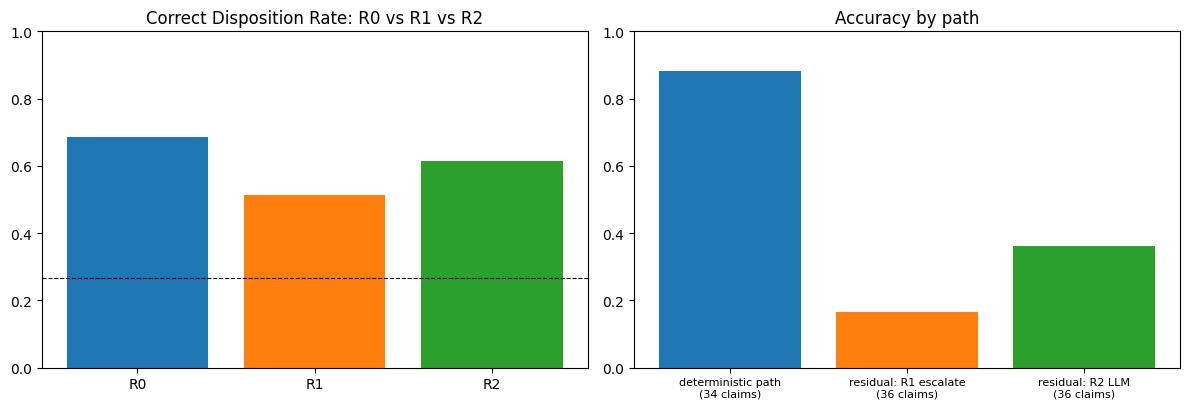

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
names = ['R0','R1','R2']; vals = [s2c['correct_disposition_rate'], s1['correct_disposition_rate'], s2['correct_disposition_rate']]
ax[0].bar(names, vals, color=['C0','C1','C2']); ax[0].axhline(0.267, ls='--', c='k', lw=.8); ax[0].set_ylim(0,1); ax[0].set_title('Correct Disposition Rate: R0 vs R1 vs R2')
ax[1].bar(['deterministic path\n(%d claims)'%len(det_ids), 'residual: R1 escalate\n(%d claims)'%len(res_ids), 'residual: R2 LLM\n(%d claims)'%len(res_ids)], [det_correct/len(det_ids), r1_on_residual/len(res_ids), llm_on_residual_correct/len(res_ids)], color=['C0','C1','C2'])
ax[1].set_ylim(0,1); ax[1].set_title('Accuracy by path'); ax[1].tick_params(axis='x', labelsize=8)
plt.tight_layout(); (C.RESULTS/'plots').mkdir(parents=True, exist_ok=True); plt.savefig(C.RESULTS/'plots'/'exp12b_resolver.png', dpi=130); plt.show()

## What was done and what it means
- **The visible-only conclusiveness signal splits the 70 dev claims 34/36**, and it is well-calibrated: the rule engine is right 88.2% of the time on the 34 claims it marks conclusive, versus 50.0% on the 36 it does not (both numbers from `src/rules_v2.py`/`src/rules_text.py`, unchanged since Exp 2c; the signal itself never reads a label, only the parser's own extraction gaps and the rule engine's own "no rule triggered" fallback string).
- **R1 vs R2, the key comparison you asked for: R2 wins clearly.** R1 (always escalate the 36 unresolved claims) scores 36/70 (51.4%) with a 65.7% human review rate — safe (0 false approvals) but expensive, the classic "escalates everything, safe but useless" pattern the plan warns about. **R2 (send the residual 36 to the LLM with RAG + Exp 12's facts) scores 43/70 (61.4%)**, human review rate down to 20%, and recovers 13 of the 36 residual claims correctly against R1's 6. **On the identical 36-claim residual subset: LLM 13/36 (36.1%) vs blind escalation 6/36 (16.7%) — the LLM is genuinely earning its place over autonomous escalation here.**
- **R2 also beats Exp 12's full hybrid (H5) while calling the LLM on half as many claims:** R2 43/70 with 36 LLM calls vs H5's 33/70 with 70 LLM calls. Routing only the genuinely unresolved cases to the LLM, and trusting the deterministic layer's conclusive decisions outright, is both more accurate and cheaper than letting the LLM re-decide every case. **Model calls avoided: 34 of 70 (49%).** Cost per residual-path claim: $0.00083, about 5,200 input tokens (RAG excerpts + facts).
- **The honest, important caveat: R0 (pure rules on all 70, including its own uncertain fallback guesses) still leads at 48/70 (68.6%), beating both R1 and R2.** Decomposed: on the same 36-claim residual subset, the rule engine's own raw fallback decision is right 18/36 (50.0%) — better than the LLM's 13/36 (36.1%) and much better than blind escalation's 6/36 (16.7%). **So neither tested degradation strategy (escalate, or hand to the LLM) yet beats simply trusting the rule engine's own uncertain answer on this dataset.** This does not mean the resolver idea is wrong; it means the *specific* conclusiveness signal used here, while well-calibrated in relative terms (88% vs 50%), marks a 36-claim group whose naive fallback answer is still informative rather than close to chance — likely because the regex parser often extracts most of what a category needs even when one field is missing, so "no rule triggered" frequently still reflects a genuinely compliant claim. **A better next step is refining the conclusiveness signal itself** (e.g., distinguishing "no rule fired and all fields were extracted" from "no rule fired only because a field was missing") so the truly low-confidence subset is smaller and worse, which is exactly where routing to escalation or the LLM should start to win outright.
- **Safety:** R1 and R2 both reach 0 false approvals (R0 has 6/52, all on the fallback-APPROVE path); FAR moves the "safety vs. usefulness" trade-off exactly where you'd expect — R1 is safest and least useful, R0 is most accurate but least safe on this metric, R2 sits in between with better accuracy than R1 at the same safety level.
- **Cost:** $0.030 for the LLM residual calls; R0/R1 cost $0. Total spend now $2.003 of $3.50.
- **Decision:** confirmed — for genuinely unresolved cases, LLM adjudication beats blind escalation (the R1 vs R2 result you asked for). But the resolver as built here does not yet beat trusting the deterministic layer outright, which is itself a useful, unflattering finding to carry into Exp 30: the router's value depends on how well "conclusive" is defined, not just on having a router shape. This is logged as an architecture probe, not the final router. Resume the original sequence: Exp 13 (missing-information detection, now framed as a component-qualification experiment), then 14, 15, 16 (reframed per your note to isolate raw records vs resolved facts vs deterministic outcome), 17-29, then Exp 30 rebuilds the final selective architecture using the winners from 12B-29, informed by this probe's caveat about calibrating conclusiveness. Validation untouched.